In [23]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_curve


In [12]:
df = pd.read_csv('global_bleaching_environmental.csv',low_memory=False)

In [13]:
df.head()

,Site_ID,Sample_ID,Data_Source,Latitude_Degrees,Longitude_Degrees,Ocean_Name,Reef_ID,Realm_Name,Ecoregion_Name,Country_Name,...,TSA_FrequencyMax,TSA_FrequencyMean,TSA_DHW,TSA_DHW_Standard_Deviation,TSA_DHWMax,TSA_DHWMean,Date,Site_Comments,Sample_Comments,Bleaching_Comments
0,2501,10324336,Donner,23.163,-82.5260,Atlantic,nd,Tropical Atlantic,Cuba and Cayman Islands,Cuba,...,5,0,0,0.74,7.25,0.18,2005-09-15,nd,nd,nd
1,3467,10324754,Donner,-17.575,-149.7833,Pacific,nd,Eastern Indo-Pacific,Society Islands French Polynesia,French Polynesia,...,4,0,0.26,0.67,4.65,0.19,1991-03-15,The bleaching does not appear to have gained ...,The bleaching does not appear to have gained ...,nd
2,1794,10323866,Donner,18.369,-64.5640,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United Kingdom,...,7,0,0,1.04,11.66,0.26,2006-01-15,nd,nd,nd
3,8647,10328028,Donner,17.760,-64.5680,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,4,0,0,0.75,5.64,0.2,2006-04-15,nd,nd,nd
4,8648,10328029,Donner,17.769,-64.5830,Atlantic,nd,Tropical Atlantic,Hispaniola Puerto Rico and Lesser Antilles,United States,...,5,0,0,0.92,6.89,0.25,2006-04-15,nd,nd,nd


In [14]:
df.replace("nd", np.nan, inplace=True)
df["Percent_Bleaching"] = pd.to_numeric(df["Percent_Bleaching"], errors="coerce")
df["Bleaching_YN"] = (df["Percent_Bleaching"] > 0).astype(int)

In [15]:
features = ["TSA", "TSA_DHW", "SSTA", "ClimSST",
            "Windspeed", "Turbidity", "Cyclone_Frequency",
            "Distance_to_Shore", "Depth_m"]

for f in features:
    df[f] = pd.to_numeric(df[f], errors="coerce")

df = df[features + ["Bleaching_YN"]].dropna()

X = df[features].values.astype(float)
y = df["Bleaching_YN"].values.astype(float).reshape(-1, 1)

print("Class balance:")
print(pd.Series(y.flatten()).value_counts())

Class balance:
0.0    23245
1.0    16177
dtype: int64


In [16]:
# normalize
X = (X - X.mean(axis=0)) / X.std(axis=0)

# train test split
np.random.seed(42)
n = len(X)
idx = np.random.permutation(n)
t, v = int(0.7*n), int(0.85*n)
X_train, y_train = X[idx[:t]],  y[idx[:t]]
X_val,   y_val   = X[idx[t:v]], y[idx[t:v]]
X_test,  y_test  = X[idx[v:]],  y[idx[v:]]

In [17]:
 # init weights
np.random.seed(42)
n_in, n_h1, n_h2, n_out = X.shape[1], 128, 64, 1

W1 = np.random.randn(n_in, n_h1) * 0.01;  b1 = np.zeros((1, n_h1))
W2 = np.random.randn(n_h1, n_h2) * 0.01;  b2 = np.zeros((1, n_h2))
W3 = np.random.randn(n_h2, n_out) * 0.01; b3 = np.zeros((1, n_out))


In [20]:
# activations & loss
def relu(z):    return np.maximum(0, z)
def sigmoid(z): return 1 / (1 + np.exp(-z))
def d_relu(z):  return (z > 0).astype(float)

def forward(X):
    z1 = X  @ W1 + b1;  a1 = relu(z1)
    z2 = a1 @ W2 + b2;  a2 = relu(z2)
    z3 = a2 @ W3 + b3;  a3 = sigmoid(z3)
    return z1, a1, z2, a2, z3, a3

def bce_weighted(y, yhat, pos_weight=1.5):
    yhat = np.clip(yhat, 1e-9, 1 - 1e-9)
    return -np.mean(pos_weight * y * np.log(yhat) + (1 - y) * np.log(1 - yhat))


In [ ]:
# training (mini batch sgd)
lr = 0.001
epochs = 2000
batch_size = 256
pos_weight = 1.5
max_wait = 100
lambda_  = 0.001
train_losses, val_losses = [], []

#  early stopping state
best_val_loss = np.inf
best_weights = None
wait = 0

for epoch in range(epochs):
    perm = np.random.permutation(len(X_train))

    for i in range(0, len(X_train), batch_size):
        b = perm[i:i + batch_size]
        Xb, yb = X_train[b], y_train[b]

        z1, a1, z2, a2, z3, a3 = forward(Xb)

        # back propagation
        dz3 = a3 - yb
        # adjust gradient for positive class weighting
        dz3 = np.where(yb == 1, pos_weight * dz3, dz3)

        dW3 = a2.T @ dz3 / len(Xb);  db3 = dz3.mean(axis=0, keepdims=True)
        dz2 = (dz3 @ W3.T) * d_relu(z2)
        dW2 = a1.T @ dz2 / len(Xb);  db2 = dz2.mean(axis=0, keepdims=True)
        dz1 = (dz2 @ W2.T) * d_relu(z1)
        dW1 = Xb.T @ dz1 / len(Xb);  db1 = dz1.mean(axis=0, keepdims=True)

        # L2 regularization
        dW1 += lambda_ * W1
        dW2 += lambda_ * W2
        dW3 += lambda_ * W3
        
        # weight update
        W3 -= lr * dW3; b3 -= lr * db3
        W2 -= lr * dW2; b2 -= lr * db2
        W1 -= lr * dW1; b1 -= lr * db1

    # epoch loss
    train_losses.append(bce_weighted(y_train, forward(X_train)[-1], pos_weight))
    val_losses.append(bce_weighted(y_val,   forward(X_val)[-1],   pos_weight))

    # early stopping
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_weights  = (W1.copy(), b1.copy(), W2.copy(), b2.copy(), W3.copy(), b3.copy())
        wait          = 0
    else:
        wait += 1
        if wait >= max_wait:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | train: {train_losses[-1]:.4f} | val: {val_losses[-1]:.4f}")

# restore best weights
W1, b1, W2, b2, W3, b3 = best_weights
print(f"\nBest val loss at epoch {np.argmin(val_losses)}")

Epoch    0 | train: 0.4882 | val: 0.5713
Epoch  200 | train: 0.4893 | val: 0.5724
Early stopping at epoch 244

Best val loss at epoch 144


In [32]:
# evaluation
y_prob = forward(X_test)[-1]
y_pred = (y_prob >= 0.5).astype(int)

print(f"\nTest Accuracy : {np.mean(y_pred == y_test):.4f}")
print(f"ROC-AUC       : {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["No Bleaching", "Bleaching"]))

# permutation feature importance
baseline_acc = np.mean((forward(X_test)[-1] >= 0.5).astype(int) == y_test)
importances  = []
for j in range(X_test.shape[1]):
    X_perm = X_test.copy()
    X_perm[:, j] = np.random.permutation(X_perm[:, j])
    acc_perm = np.mean((forward(X_perm)[-1] >= 0.5).astype(int) == y_test)
    importances.append(baseline_acc - acc_perm)



Test Accuracy : 0.7678
ROC-AUC       : 0.8557

Classification Report:
              precision    recall  f1-score   support

No Bleaching       0.83      0.77      0.80      3482
   Bleaching       0.70      0.77      0.73      2432

    accuracy                           0.77      5914
   macro avg       0.76      0.77      0.76      5914
weighted avg       0.77      0.77      0.77      5914



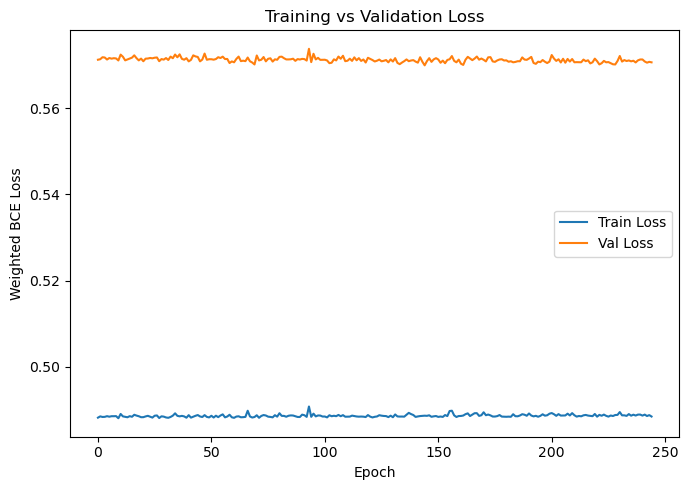

In [ ]:
# loss curve
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(train_losses, label="Train Loss")
ax.plot(val_losses,   label="Val Loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Weighted BCE Loss")
ax.set_title("Training vs Validation Loss")
ax.legend()
plt.tight_layout()
plt.savefig("loss_curve.png", dpi=150)
plt.show()

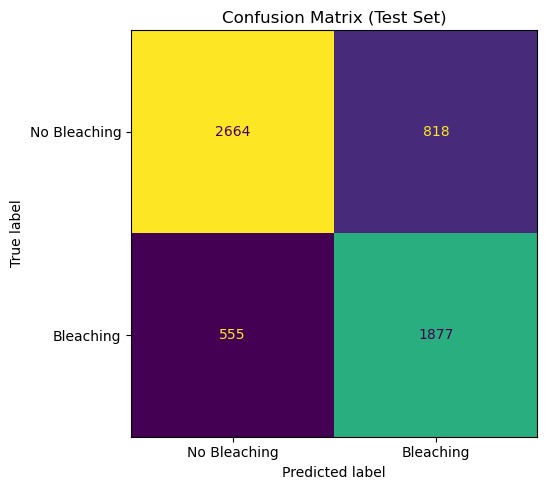

In [ ]:
# confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=["No Bleaching", "Bleaching"]).plot(
    ax=ax, colorbar=False)
ax.set_title("Confusion Matrix (Test Set)")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
plt.show()

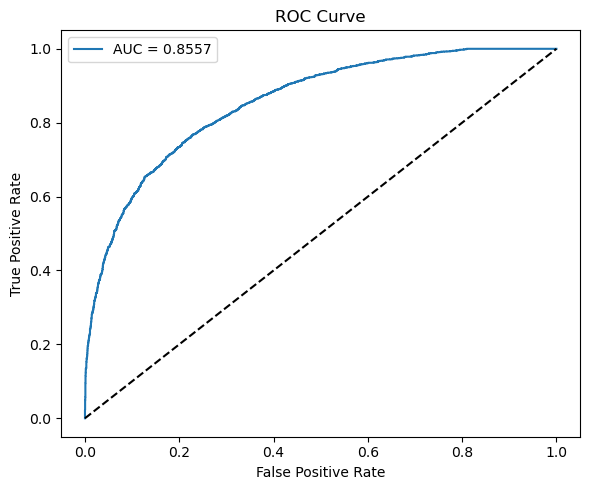

In [ ]:
# ROC curve
fig, ax = plt.subplots(figsize=(6, 5))
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score   = roc_auc_score(y_test, y_prob)
ax.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}")
ax.plot([0,1], [0,1], "k--")
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve"); ax.legend()
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150)
plt.show()

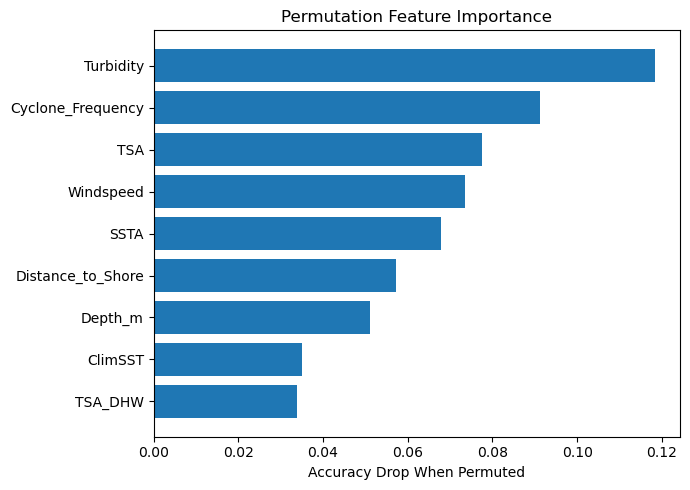

In [ ]:
# feature importance
fig, ax = plt.subplots(figsize=(7, 5))
sorted_idx = np.argsort(importances)
ax.barh([features[i] for i in sorted_idx], [importances[i] for i in sorted_idx])
ax.set_xlabel("Accuracy Drop When Permuted")
ax.set_title("Permutation Feature Importance")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150)
plt.show()